In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=pd.errors.SettingWithCopyWarning)

df = pd.read_csv("Online Retail.csv")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df_clean = df.dropna().drop_duplicates()
df_filter = df_clean[
    ~df_clean['InvoiceNo'].str.contains("C")
]
df_rfm = df_filter[
    (df_filter['UnitPrice'] != 0) & (df_filter['Quantity'] > 0)
]
#Data untuk RFM harus menggunakan data yang benar benar bersih untuk menghasilkan segmentasi yang akurat
df_rfm['Total Price'] = df_rfm['Quantity'] * df_rfm['UnitPrice']
df_rfm

C:\Users\ASUS\AppData\Local\Temp\ipykernel_66816\3878211917.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rfm['Total Price'] = df_rfm['Quantity'] * df_rfm['UnitPrice']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total Price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


## Data Cleaning

Pada tahap ini dilakukan pembersihan data untuk memastikan analisis RFM dan Market Basket Analysis menghasilkan insight yang akurat dan objektif.

Langkah pembersihan data meliputi:
- Menghapus transaksi dengan nilai kosong (missing values)
- Menghapus duplikasi data
- Menghilangkan transaksi pembatalan (InvoiceNo mengandung huruf "C")
- Menghapus transaksi dengan nilai Quantity ≤ 0 atau UnitPrice = 0

Hasil dari tahap ini adalah dataset bersih (`df_rfm`) yang merepresentasikan transaksi pembelian nyata pelanggan.

In [78]:
snapshot = df_rfm['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_rfm.groupby(['CustomerID']).agg({
    'InvoiceDate':lambda x:(snapshot - x.max()).days,
    'InvoiceNo':'nunique',
    'Total Price':'sum' 
}).rename(columns = {'InvoiceDate':'Recency', 'InvoiceNo':'Frequency', 'Total Price':'Monetary'})

rfm['Monetary_Log'] = np.log1p(rfm['Monetary'])

rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=(5,4,3,2,1))
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=(1,2,3,4,5))
rfm['M_Score'] = pd.qcut(rfm['Monetary_Log'], 5, labels=(1,2,3,4,5))

def segment_customer(row):
    R, F, M = row['R_Score'], row['F_Score'], row['M_Score']

    if R >= 4 and F >= 4 and M >= 4:
        return 'Loyalist'
    elif R >= 4 and F >= 3 and M <= 3:
        return 'Potential Loyalist'
    elif R <= 2 and F >= 3 and M >= 3:
        return 'At Risk High Value'
    elif R >= 4 and F <= 2 and M <= 2:
        return 'New Customer'
    else:
        return 'Regular'
    
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

rfm['Segmentasi'] = rfm.apply(segment_customer, axis=1)
rfm

,Recency,Frequency,Monetary,Monetary_Log,R_Score,F_Score,M_Score,RFM_Score,Segmentasi
CustomerID,,,,,,,,,
12346.0,326,1,77183.60,11.253955,1,1,5,115,Regular
12347.0,2,7,4310.00,8.368925,5,5,5,555,Loyalist
12348.0,75,4,1797.24,7.494564,2,4,4,244,At Risk High Value
12349.0,19,1,1757.55,7.472245,4,1,4,414,Regular
12350.0,310,1,334.40,5.815324,1,1,2,112,Regular
...,...,...,...,...,...,...,...,...,...
18280.0,278,1,180.60,5.201806,1,2,1,121,Regular
18281.0,181,1,80.82,4.404522,1,2,1,121,Regular
18282.0,8,2,178.05,5.187665,5,3,1,531,Potential Loyalist


## Feature Engineering

Setelah data bersih, dibuat fitur tambahan yang dibutuhkan untuk analisis:

- **Total Price**: nilai total transaksi (Quantity × UnitPrice)
- **Recency**: jarak hari sejak transaksi terakhir pelanggan
- **Frequency**: jumlah transaksi pelanggan
- **Monetary**: total nilai belanja pelanggan

Fitur-fitur ini digunakan sebagai dasar segmentasi pelanggan dan analisis perilaku pembelian.


## Monetary Value Insight

Distribusi nilai belanja pelanggan menunjukkan ketimpangan yang signifikan, di mana sebagian kecil pelanggan memiliki nilai transaksi yang sangat tinggi.

Untuk mengurangi efek ekstrem tersebut, dilakukan log transformation pada nilai Monetary. Pendekatan ini membuat distribusi data lebih seimbang sehingga segmentasi pelanggan menjadi lebih adil dan representatif.

In [ ]:
df_mba = df[
    (~df['InvoiceNo'].str.contains("C")) &
    (df['UnitPrice'] != 0) & 
    (df['Quantity'] >= 0) &
    (df['Country'] == 'United Kingdom')
]
df_mba
#Data untuk MBA lebih fleksibel karena hanya berfokus pada InvoiceNo dan StockCode, tapi tetap harus menghapus transaksi yang dicancel

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12,2011-12-09 12:31:00,1.95,15804.0,United Kingdom
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,2011-12-09 12:49:00,2.95,13113.0,United Kingdom
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,2011-12-09 12:49:00,1.25,13113.0,United Kingdom
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,2011-12-09 12:49:00,8.95,13113.0,United Kingdom


## Data Preparation for Market Basket Analysis

Data transaksi disiapkan dalam format yang sesuai untuk Market Basket Analysis, di mana setiap baris merepresentasikan satu transaksi dan setiap kolom menunjukkan keberadaan suatu produk.

Tahap ini memastikan bahwa pola yang dihasilkan mencerminkan perilaku pembelian pelanggan secara aktual.


In [94]:
basket = df_mba.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().fillna(0)

def encode_cells(x):
    return 1 if x >= 1 else 0

basket_sets = basket.applymap(encode_cells)
basket_sets

C:\Users\ASUS\AppData\Local\Temp\ipykernel_66816\1595154603.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_sets = basket.applymap(encode_cells)


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,TOADSTOOL BEDSIDE LIGHT,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581585,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
581586,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A563185,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Apriori Algorithm Implementation

Algoritma Apriori digunakan untuk mengekstraksi frequent itemsets berdasarkan nilai minimum support tertentu.

Dalam proyek ini, dilakukan eksperimen dengan beberapa nilai minimum support untuk menemukan keseimbangan antara:
- Jumlah itemset yang dihasilkan
- Kualitas dan relevansi pola pembelian


In [101]:
from mlxtend.frequent_patterns import apriori

frequent_items = apriori(
    basket_sets,
    min_support = 0.03,
    use_colnames = True
)

frequent_items.sort_values('support', ascending=False)

c:\Users\ASUS\Documents\Project1\env\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
128,0.119971,(WHITE HANGING HEART T-LIGHT HOLDER)
55,0.107375,(JUMBO BAG RED RETROSPOT)
102,0.093502,(REGENCY CAKESTAND 3 TIER)
90,0.088397,(PARTY BUNTING)
73,0.077243,(LUNCH BAG RED RETROSPOT)
...,...,...
76,0.030242,(LUNCH BAG VINTAGE DOILY )
144,0.030242,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY..."
82,0.030187,(PACK OF 60 DINOSAUR CAKE CASES)
130,0.030132,(WOODEN BOX OF DOMINOES)


## Minimum Support Selection

Hasil eksperimen menunjukkan bahwa:
- Minimum support 0.02 menghasilkan jumlah itemset yang lebih banyak namun cenderung lebih kompleks
- Minimum support 0.03 menghasilkan itemset yang lebih sedikit namun lebih stabil dan relevan secara bisnis

Oleh karena itu, analisis lanjutan difokuskan pada minimum support 0.03 untuk menjaga kualitas insight yang dihasilkan.


In [103]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_items,
    metric = 'lift',
    min_threshold = 1
)

filtered_rules = rules[
    (rules['confidence'] >= 0.4) &
    (rules['lift'] >= 1.2)
]

filtered_rules.sort_values('lift', ascending = False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
4,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.051717,0.038955,0.031963,0.618026,15.865302,1.0,0.029948,2.515995,0.988070,0.544423,0.602543,0.719269
5,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.038955,0.051717,0.031963,0.820513,15.865302,1.0,0.029948,5.283289,0.974948,0.544423,0.810724,0.719269
20,(PINK REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.038955,0.053049,0.030242,0.776353,14.634584,1.0,0.028176,4.234137,0.969433,0.489668,0.763824,0.673218
21,(ROSES REGENCY TEACUP AND SAUCER ),(PINK REGENCY TEACUP AND SAUCER),0.053049,0.038955,0.030242,0.570084,14.634584,1.0,0.028176,2.235424,0.983862,0.489668,0.552658,0.673218
3,(GARDENERS KNEELING PAD CUP OF TEA ),(GARDENERS KNEELING PAD KEEP CALM ),0.041618,0.049831,0.030021,0.721333,14.475666,1.0,0.027947,3.409698,0.971344,0.488708,0.706719,0.661892
2,(GARDENERS KNEELING PAD KEEP CALM ),(GARDENERS KNEELING PAD CUP OF TEA ),0.049831,0.041618,0.030021,0.602450,14.475666,1.0,0.027947,2.410720,0.979740,0.488708,0.585186,0.661892
6,(GREEN REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.051717,0.053049,0.038844,0.751073,14.158040,1.0,0.036100,3.804130,0.980055,0.589226,0.737128,0.741645
7,(ROSES REGENCY TEACUP AND SAUCER ),(GREEN REGENCY TEACUP AND SAUCER),0.053049,0.051717,0.038844,0.732218,14.158040,1.0,0.036100,3.541243,0.981433,0.589226,0.717613,0.741645
1,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED ),0.048610,0.051606,0.031241,0.642694,12.453752,1.0,0.028733,2.654290,0.966694,0.452936,0.623251,0.624035
0,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE GREEN),0.051606,0.048610,0.031241,0.605376,12.453752,1.0,0.028733,2.410879,0.969748,0.452936,0.585214,0.624035


## Association Rules Generation

Dari frequent itemsets yang terbentuk, dibuat association rules untuk mengukur kekuatan hubungan antar produk.

Metrik utama yang digunakan adalah:
- **Support**: seberapa sering kombinasi produk muncul
- **Confidence**: tingkat kemungkinan pembelian produk B setelah membeli produk A
- **Lift**: kekuatan hubungan dibandingkan pembelian acak


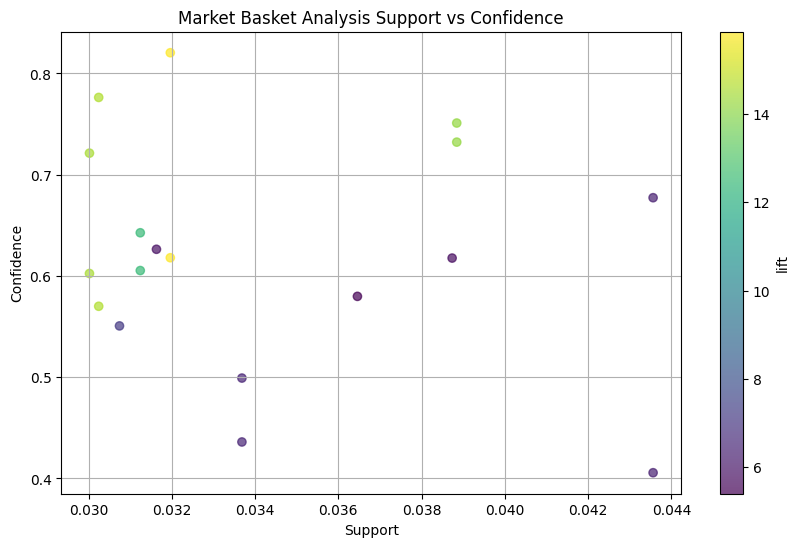

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
scatter = plt.scatter(
    filtered_rules['support'],
    filtered_rules['confidence'],
    c=filtered_rules['lift'],
    cmap='viridis',
    alpha=0.7
)

plt.colorbar(scatter, label='lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Market Basket Analysis Support vs Confidence')
plt.grid(True)
plt.show()

## Support vs Confidence Analysis

Visualisasi hubungan antara support dan confidence digunakan untuk:
- Mengidentifikasi rules dengan keseimbangan terbaik antara frekuensi dan kekuatan hubungan
- Menyaring rules yang jarang terjadi namun memiliki confidence tinggi
- Membantu pemilihan rules yang paling relevan untuk implementasi bisnis


In [111]:
filtered_rules[
    (filtered_rules['support'] > 0.03) &
    (filtered_rules['confidence'] > 0.6)
].sort_values(['support', 'confidence'], ascending=False).drop_duplicates(subset=['consequents'])

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
10,(JUMBO BAG PINK POLKADOT),(JUMBO BAG RED RETROSPOT),0.064314,0.107375,0.043560,0.677308,6.307890,1.0,0.036655,2.766184,0.899306,0.339974,0.638491,0.541496
6,(GREEN REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.051717,0.053049,0.038844,0.751073,14.158040,1.0,0.036100,3.804130,0.980055,0.589226,0.737128,0.741645
7,(ROSES REGENCY TEACUP AND SAUCER ),(GREEN REGENCY TEACUP AND SAUCER),0.053049,0.051717,0.038844,0.732218,14.158040,1.0,0.036100,3.541243,0.981433,0.589226,0.717613,0.741645
4,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.051717,0.038955,0.031963,0.618026,15.865302,1.0,0.029948,2.515995,0.988070,0.544423,0.602543,0.719269
1,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED ),0.048610,0.051606,0.031241,0.642694,12.453752,1.0,0.028733,2.654290,0.966694,0.452936,0.623251,0.624035
0,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE GREEN),0.051606,0.048610,0.031241,0.605376,12.453752,1.0,0.028733,2.410879,0.969748,0.452936,0.585214,0.624035
3,(GARDENERS KNEELING PAD CUP OF TEA ),(GARDENERS KNEELING PAD KEEP CALM ),0.041618,0.049831,0.030021,0.721333,14.475666,1.0,0.027947,3.409698,0.971344,0.488708,0.706719,0.661892
2,(GARDENERS KNEELING PAD KEEP CALM ),(GARDENERS KNEELING PAD CUP OF TEA ),0.049831,0.041618,0.030021,0.602450,14.475666,1.0,0.027947,2.410720,0.979740,0.488708,0.585186,0.661892


## Selection of High-Quality Rules

Untuk memastikan insight yang dihasilkan dapat ditindaklanjuti secara bisnis, dilakukan penyaringan association rules dengan kriteria:
- Support ≥ 3%
- Confidence ≥ 60%
- Lift > 1

Kriteria ini dipilih untuk menyeimbangkan antara frekuensi kemunculan dan kekuatan hubungan antar produk.


## Key Insights from Association Rules

Hasil akhir menunjukkan 12 association rules yang memenuhi kriteria kualitas.

Rules ini mengindikasikan bahwa pelanggan yang membeli produk tertentu memiliki kecenderungan kuat untuk membeli produk lain secara bersamaan. Pola ini mencerminkan perilaku belanja yang konsisten dan dapat dimanfaatkan untuk strategi peningkatan penjualan.


## Executive Summary
Analisis ini bertujuan untuk memahami perilaku pelanggan dan pola pembelian produk berdasarkan dataset transaksi online retail pada periode tahun 2010–2011. Proses analisis diawali dengan data cleaning untuk memastikan data yang digunakan bebas dari missing value, transaksi yang dibatalkan (canceled transaction), nilai nol, serta data duplikat, sehingga kualitas data terjaga dengan baik.

Selanjutnya, dilakukan Exploratory Data Analysis (EDA) untuk mengidentifikasi variabel dan subset data yang relevan, sehingga analisis dapat dilakukan secara lebih fokus dan efisien. Untuk menganalisis perilaku pelanggan, digunakan metode RFM Analysis yang mengelompokkan pelanggan ke dalam lima segmen berdasarkan recency, frequency, dan monetary value. Sementara itu, pola pembelian produk dianalisis menggunakan Market Basket Analysis dengan memanfaatkan metrik support, confidence, dan lift dari association rules.

Kombinasi kedua pendekatan ini menghasilkan insight berbasis data yang dapat digunakan perusahaan sebagai dasar pengambilan keputusan strategis, seperti optimalisasi penjualan, peningkatan efektivitas pemasaran, serta penguatan hubungan dan kepercayaan pelanggan di setiap segmen.


## Key Insight - RFM Analysis
Hasil analisis RFM menunjukkan adanya perbedaan perilaku pelanggan yang cukup jelas antar segmen, yang mencerminkan tingkat keterlibatan dan nilai kontribusi pelanggan terhadap perusahaan.

- **Loyalist** memiliki frekuensi transaksi tinggi dan pola pembelian yang konsisten, sehingga menjadi kontributor utama terhadap pendapatan perusahaan.
- **New Customers** masih aktif bertransaksi, namun belum menunjukkan loyalitas jangka panjang dan membutuhkan strategi onboarding yang tepat.
- **Potential Loyalist** memiliki potensi untuk ditingkatkan nilainya melalui pendekatan pemasaran dan promosi yang terarah.
- **At Risk High Value** menunjukkan penurunan aktivitas transaksi dan memiliki risiko churn meskipun sebelumnya bernilai tinggi.

Segmentasi ini memungkinkan perusahaan untuk menerapkan strategi pemasaran yang lebih terarah, efisien, dan sesuai dengan karakteristik masing-masing kelompok pelanggan.

## Key Insight - Market Basket Analysis
Berdasarkan hasil Market Basket Analysis pada transaksi di United Kingdom, ditemukan beberapa kombinasi produk dengan hubungan pembelian yang sangat kuat. Itemset terpilih memiliki nilai support di atas 3%, confidence di atas 60%, serta lift lebih dari 5, yang menunjukkan bahwa hubungan antar produk bersifat signifikan dan tidak terjadi secara kebetulan.

Temuan ini membuka peluang besar bagi perusahaan untuk menerapkan strategi bundling dan rekomendasi produk. Beberapa pola pembelian utama yang dapat ditindaklanjuti antara lain:

1. Pelanggan yang membeli **JUMBO BAG PINK POLKADOT** memiliki kemungkinan **68%** untuk membeli **JUMBO BAG RED RETROSPOT** (lift 6.3).
2. Pembelian **GREEN REGENCY TEACUP AND SAUCER** meningkatkan kemungkinan pembelian **ROSES REGENCY TEACUP AND SAUCER** sebesar **75%** (lift 14.2).
3. Sebaliknya, pembelian **ROSES REGENCY TEACUP AND SAUCER** juga meningkatkan peluang pembelian **GREEN REGENCY TEACUP AND SAUCER** sebesar **73%** (lift 14.2).
4. Pembelian **GREEN REGENCY TEACUP AND SAUCER** meningkatkan peluang pembelian **PINK REGENCY TEACUP AND SAUCER** sebesar **61%** (lift 15.9).
5. Pelanggan yang membeli **ALARM CLOCK BAKELIKE GREEN** memiliki kemungkinan **64%** membeli **ALARM CLOCK BAKELIKE RED** (lift 12.4).
6. Pola serupa juga ditemukan sebaliknya, di mana pembelian **ALARM CLOCK BAKELIKE RED** meningkatkan peluang pembelian **ALARM CLOCK BAKELIKE GREEN** sebesar **60%** (lift 12.4).
7. Pembelian **GARDENERS KNEELING PAD CUP OF TEA** meningkatkan kemungkinan **72%** pembelian **GARDENERS KNEELING PAD KEEP CALM** (lift 14.5).
8. Sebaliknya, pembelian **GARDENERS KNEELING PAD KEEP CALM** juga meningkatkan peluang pembelian **GARDENERS KNEELING PAD CUP OF TEA** sebesar **60%** (lift 14.5).


## Business Recommendation
Berdasarkan hasil analisis yang dilakukan, beberapa rekomendasi strategis yang dapat diterapkan oleh perusahaan adalah sebagai berikut:

1. Memanfaatkan itemset dengan nilai confidence dan lift yang tinggi untuk menerapkan strategi bundling dan cross-selling guna meningkatkan nilai transaksi rata-rata.
2. Menggunakan segmentasi RFM sebagai dasar personalisasi campaign pemasaran agar pesan dan penawaran lebih relevan bagi setiap kelompok pelanggan.
3. Mengembangkan program loyalitas khusus bagi pelanggan dengan segmen **Loyalist** dan **Potential Loyalist** untuk meningkatkan retensi dan pembelian berulang.
4. Menyusun strategi reaktivasi bagi pelanggan **At Risk** dengan memberikan penawaran berbasis riwayat produk yang sebelumnya sering dibeli.
5. Memberikan event yang bertepatan dengan tanggal tanggal tertentu untuk menarik meningkatkan frekuensi belanja bagi pelanggan dengan segmen **New Customer**

## Conclusion
Melalui analisis ini, perusahaan memperoleh pemahaman yang lebih baik mengenai perilaku pelanggan serta pola pembelian produk pada bisnis online retail. Insight yang dihasilkan dari RFM Analysis dan Market Basket Analysis diharapkan dapat membantu perusahaan dalam memaksimalkan penjualan, meningkatkan efektivitas pemasaran, serta membangun hubungan jangka panjang dengan pelanggan.

Meskipun demikian, analisis ini masih memiliki keterbatasan, seperti belum mempertimbangkan faktor musiman dan nilai pelanggan dalam jangka panjang. Ke depannya, analisis dapat dikembangkan lebih lanjut dengan menambahkan pendekatan Customer Lifetime Value (CLV) atau analisis time series untuk mendukung pengambilan keputusan bisnis yang lebih komprehensif.
